In [24]:
# ------------------------------------------------------------
# Decision Tree on sklearn Digits Dataset (Hands-on)
# Steps:
# 1) Load data
# 2) Visualize some digits with labels
# 3) Standard scaling
# 4) Train-test split
# 5) Train Decision Tree
# 6) Evaluate (accuracy)
# ------------------------------------------------------------


In [25]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits  # digits data import
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

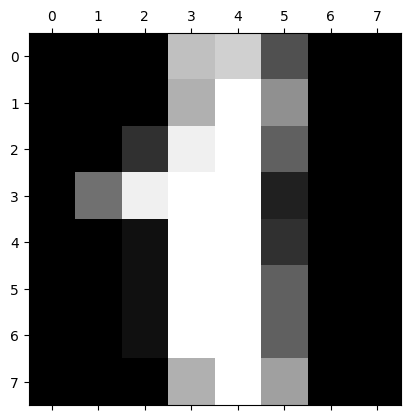

In [26]:
# 1) Load data
digits = load_digits()
#plt.gray()
plt.matshow(digits.images[1])
plt.show()

In [27]:
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [28]:
x = digits.data
y = digits.target
images = digits.images

print("X shape:", x.shape)
print("y shape:", y.shape)
print("images shape:", images.shape)
print("Unique classes:", np.unique(y))

X shape: (1797, 64)
y shape: (1797,)
images shape: (1797, 8, 8)
Unique classes: [0 1 2 3 4 5 6 7 8 9]


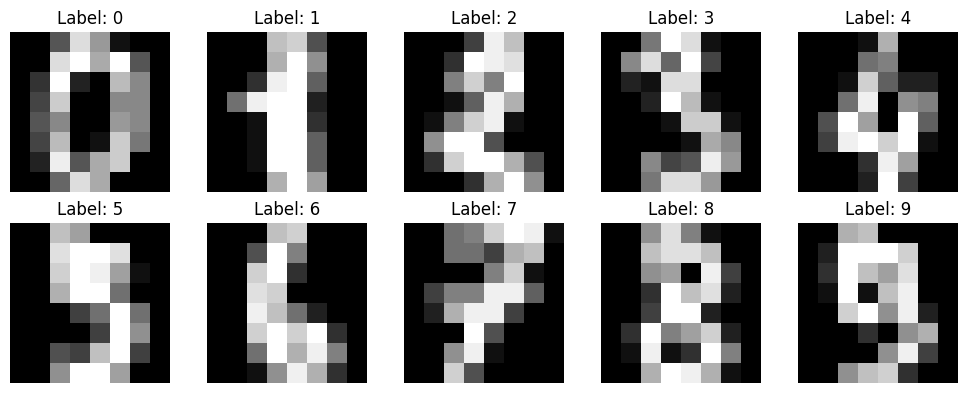

In [29]:
# -----------------------------------------
# 2) Visualize some digits with their labels
# -----------------------------------------

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.ravel()
for i in range(10):
  axes[i].imshow(digits.images[i], cmap= 'gray')
  axes[i].set_title(f'Label: {digits.target[i]}')
  axes[i].axis('off')


plt.tight_layout()
plt.show()

In [30]:
# -----------------------------------------
# 3) Standard Scaling (requested)
# -----------------------------------------
# Scaling makes features have mean ~0 and std ~1.
# NOTE: Trees do NOT require scaling. Tree-based models (Decision Trees, Random Forest, Gradient Boosting) do not require scaling
#because they are rule-based, not distance-based.
#They split nodes based on the order of values (e.g.,) rather than the magnitude of distances, making them invariant to monotonic transformations like scaling.

scaler = StandardScaler()
x = scaler.fit_transform(x)

In [31]:
# -----------------------------------------
# 4) Train-test split (before scaling)
# -----------------------------------------

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.2,
    random_state =42,
    stratify = y  # keeps class distribution similar in train/test
)

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

Train: (1437, 64) (1437,)
Test : (360, 64) (360,)


In [32]:
# -----------------------------------------
# 5) Train Decision Tree classifier
# -----------------------------------------
# max_depth controls complexity (helps reduce overfitting)
# You can change max_depth to see how performance changes.

dt = DecisionTreeClassifier(
    criterion = 'gini',
    max_depth = 10
)

dt.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=10)

In [34]:
# -----------------------------------------
# 6) Evaluate the model
# -----------------------------------------

y_pred = dt.predict(x_test)
acc = accuracy_score(y_test, y_pred)

print('Accuracy:', acc)

Accuracy: 0.8416666666666667
